# Taller: Segmentando el Mundo - Binarización y Reconocimiento de Formas

Este notebook implementa técnicas de segmentación de imágenes mediante umbralización y detección de formas.

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from pathlib import Path

# Crear carpeta de salida para resultados
OUTPUT_DIR = '../media'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Generar imagen de ejemplo con formas simples

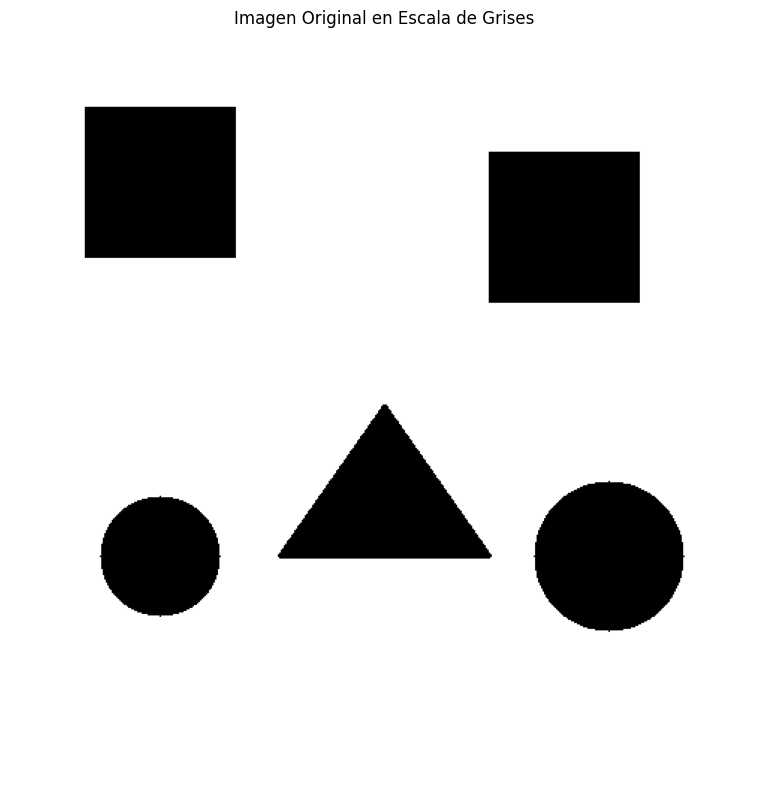

Imagen original creada: (500, 500)


In [ ]:
# Cargar imagen en escala de grises
img_path = '../media/IMAGEN_EN_ESCALA_DE_GRISES.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Verificar que la imagen se cargó correctamente
if img is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen desde: {img_path}")

print(f"Imagen cargada correctamente: {img.shape}")
print(f"Tipo de dato: {img.dtype}")
print(f"Rango de valores: [{img.min()}, {img.max()}]")

# Mostrar imagen original
plt.figure(figsize=(12, 8))
plt.imshow(img, cmap='gray')
plt.title('Imagen Original en Escala de Grises')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_imagen_original_viz.png'), dpi=100, bbox_inches='tight')
plt.show()

# Guardar imagen original también en formato PNG para referencia
cv2.imwrite(os.path.join(OUTPUT_DIR, '01_imagen_original.png'), img)

## 3. Segmentación Binaria - Umbral Fijo

Valor de umbral retornado: 127.0
Imagen binaria con umbral fijo: (500, 500)


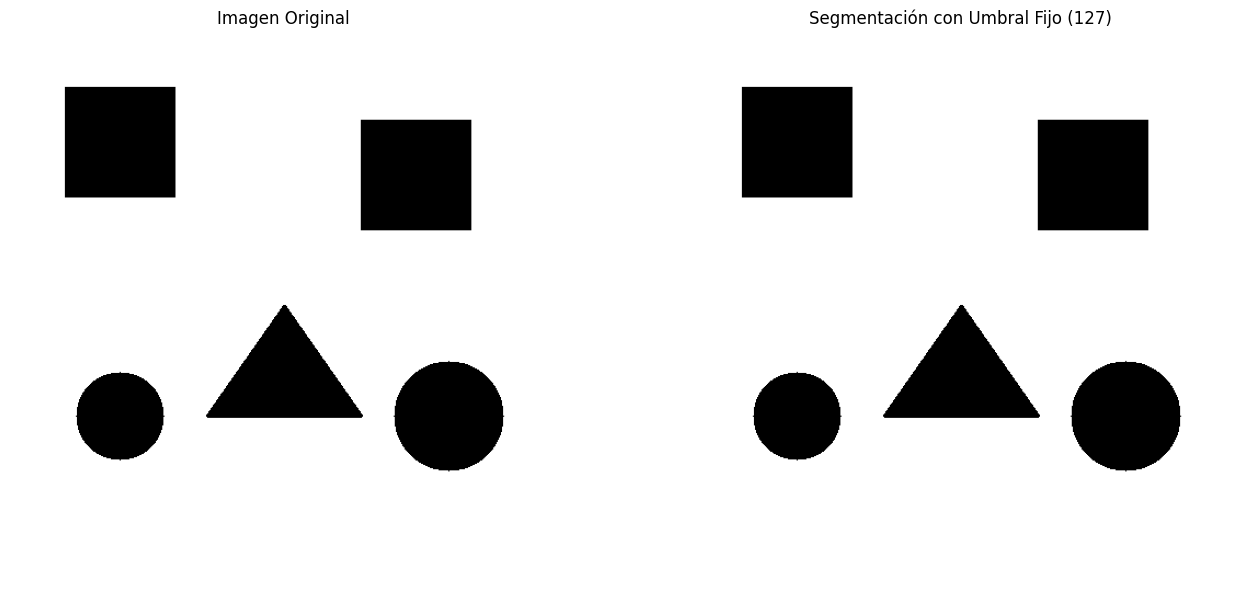

In [3]:
# Aplicar umbral fijo
# Cualquier píxel con valor < 128 se convierte a 0, > 128 a 255
ret, binary_fixed = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

print(f"Valor de umbral retornado: {ret}")
print(f"Imagen binaria con umbral fijo: {binary_fixed.shape}")

# Guardar resultado
cv2.imwrite(os.path.join(OUTPUT_DIR, '02_umbral_fijo.png'), binary_fixed)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(binary_fixed, cmap='gray')
axes[1].set_title('Segmentación con Umbral Fijo (127)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_umbral_fijo_viz.png'), dpi=100, bbox_inches='tight')
plt.show()

## 4. Segmentación Binaria - Umbral Adaptativo

Imagen binaria con umbral adaptativo: (500, 500)


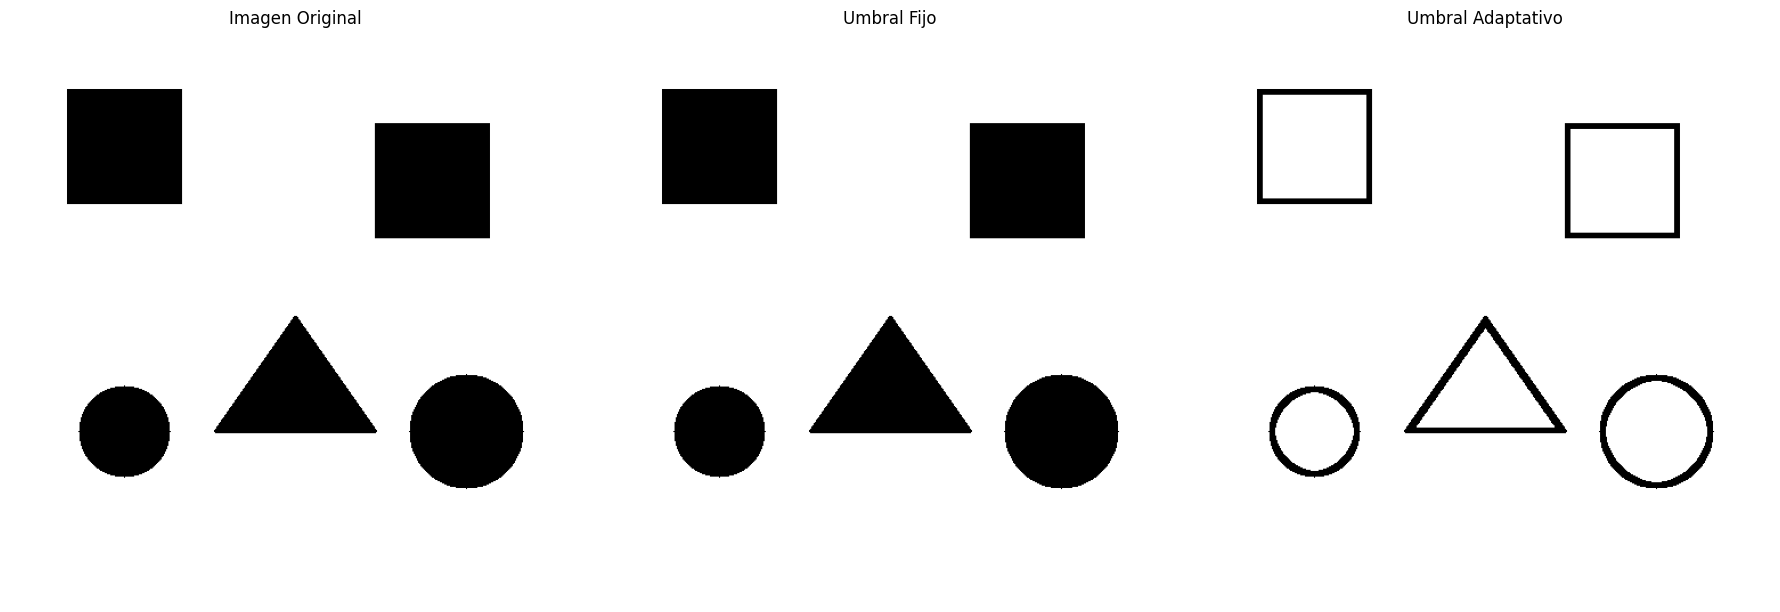

In [4]:
# Aplicar umbral adaptativo
# El umbral se calcula para pequeñas regiones de la imagen
binary_adaptive = cv2.adaptiveThreshold(
    img, 
    255, 
    cv2.ADAPTIVE_THRESH_MEAN_C, 
    cv2.THRESH_BINARY, 
    blockSize=11, 
    C=2
)

print(f"Imagen binaria con umbral adaptativo: {binary_adaptive.shape}")

# Guardar resultado
cv2.imwrite(os.path.join(OUTPUT_DIR, '03_umbral_adaptativo.png'), binary_adaptive)

# Visualizar comparación
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(binary_fixed, cmap='gray')
axes[1].set_title('Umbral Fijo')
axes[1].axis('off')

axes[2].imshow(binary_adaptive, cmap='gray')
axes[2].set_title('Umbral Adaptativo')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_comparacion_umbrales.png'), dpi=100, bbox_inches='tight')
plt.show()

## 5. Detección de Contornos

In [5]:
# Detectar contornos en la imagen binarizada (usando umbral fijo)
contours, hierarchy = cv2.findContours(
    binary_fixed, 
    cv2.RETR_TREE, 
    cv2.CHAIN_APPROX_SIMPLE
)

print(f"Número de contornos detectados: {len(contours)}")
print(f"Información de jerarquía: {hierarchy}")

# Mostrar información de cada contorno
for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    print(f"Contorno {i}: Área={area:.2f}, Perímetro={perimeter:.2f}")

Número de contornos detectados: 6
Información de jerarquía: [[[-1 -1  1 -1]
  [ 2 -1 -1  0]
  [ 3  1 -1  0]
  [ 4  2 -1  0]
  [ 5  3 -1  0]
  [-1  4 -1  0]]]
Contorno 0: Área=249001.00, Perímetro=1996.00
Contorno 1: Área=5138.00, Perímetro=269.42
Contorno 2: Área=7986.00, Perímetro=335.36
Contorno 3: Área=7801.00, Perímetro=410.48
Contorno 4: Área=10402.00, Perímetro=405.66
Contorno 5: Área=10402.00, Perímetro=405.66


## 6. Dibujar Contornos sobre la Imagen Original

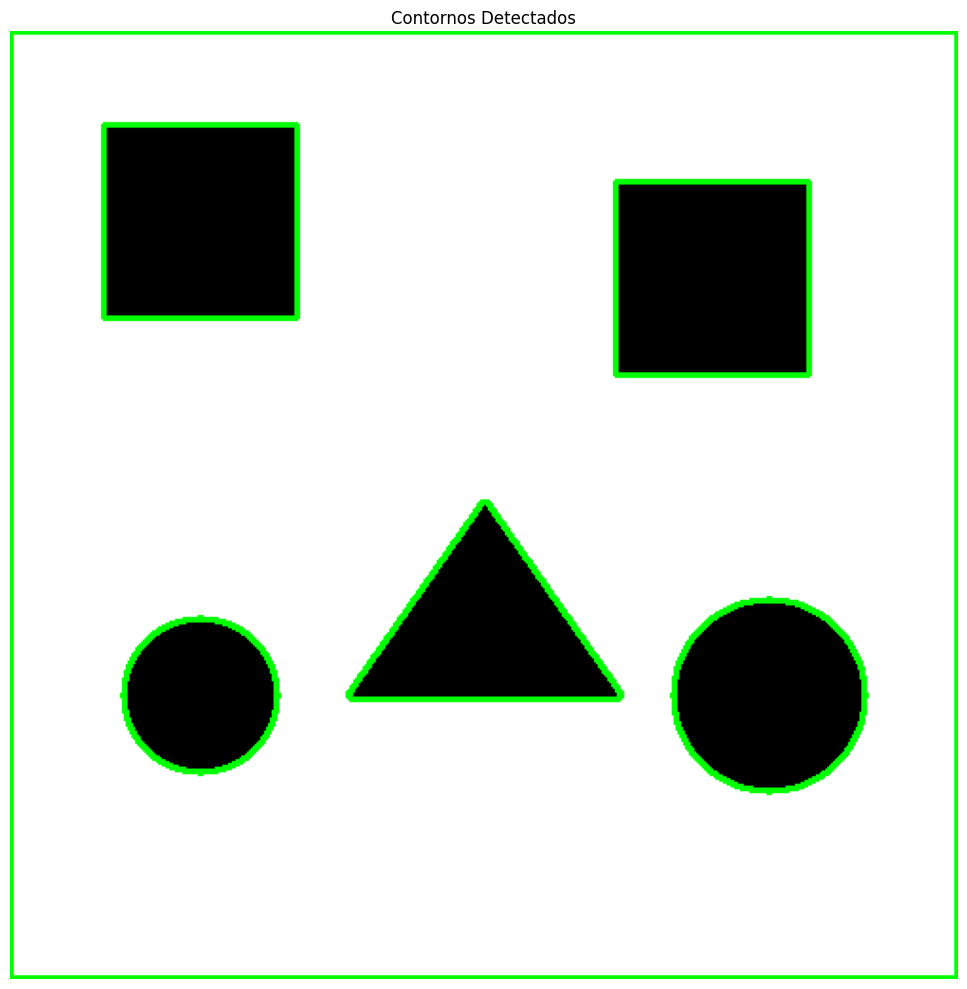

In [6]:
# Crear copia de la imagen original para dibujar
img_contours = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Dibujar contornos en color
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# Guardar resultado
cv2.imwrite(os.path.join(OUTPUT_DIR, '04_contornos_dibujados.png'), img_contours)

# Mostrar imagen con contornos
plt.figure(figsize=(10, 10))
img_contours_rgb = cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB)
plt.imshow(img_contours_rgb)
plt.title('Contornos Detectados')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_contornos_dibujados_viz.png'), dpi=100, bbox_inches='tight')
plt.show()

## 7. Cálculo de Centro de Masa (Momentos)

In [7]:
# Calcular centro de masa para cada contorno
centers = []
moments_data = []

for i, contour in enumerate(contours):
    M = cv2.moments(contour)
    
    # Evitar división por cero
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        centers.append((cx, cy))
        moments_data.append({
            'id': i,
            'cx': cx,
            'cy': cy,
            'area': cv2.contourArea(contour),
            'perimeter': cv2.arcLength(contour, True)
        })
        print(f"Contorno {i}: Centro de masa = ({cx}, {cy})")

print(f"\nTotal de centros de masa calculados: {len(centers)}")

Contorno 0: Centro de masa = (249, 249)
Contorno 1: Centro de masa = (100, 350)
Contorno 2: Centro de masa = (400, 350)
Contorno 3: Centro de masa = (250, 316)
Contorno 4: Centro de masa = (370, 130)
Contorno 5: Centro de masa = (100, 100)

Total de centros de masa calculados: 6


## 8. Cálculo de Bounding Boxes

Contorno 0: BBox = (0, 0, 500, 500)
Contorno 1: BBox = (59, 309, 83, 83)
Contorno 2: BBox = (349, 299, 103, 103)
Contorno 3: BBox = (178, 248, 145, 105)
Contorno 4: BBox = (319, 79, 103, 103)
Contorno 5: BBox = (49, 49, 103, 103)


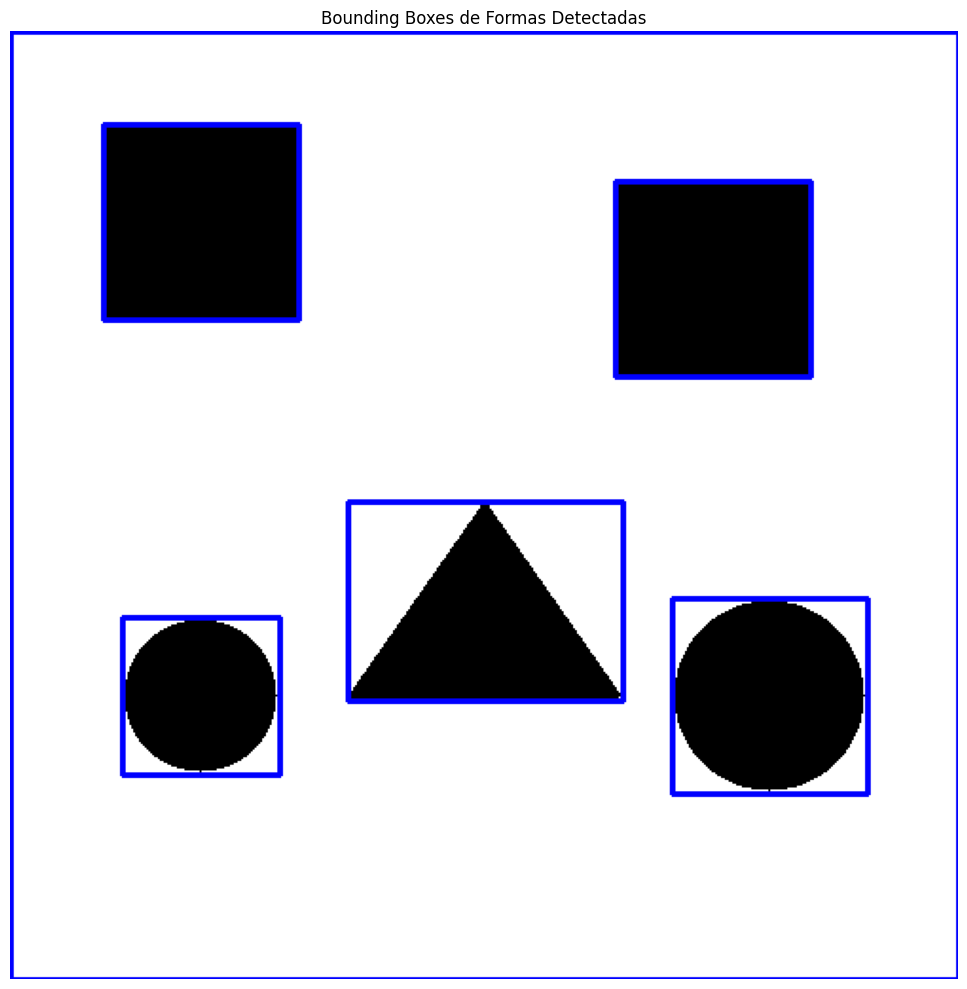

In [8]:
# Calcular bounding boxes para cada contorno
img_bbox = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

bounding_boxes = []

for i, contour in enumerate(contours):
    x, y, w, h = cv2.boundingRect(contour)
    bounding_boxes.append({
        'id': i,
        'x': x,
        'y': y,
        'width': w,
        'height': h,
        'area_bbox': w * h
    })
    
    # Dibujar rectángulo
    cv2.rectangle(img_bbox, (x, y), (x + w, y + h), (255, 0, 0), 2)
    print(f"Contorno {i}: BBox = ({x}, {y}, {w}, {h})")

# Guardar resultado
cv2.imwrite(os.path.join(OUTPUT_DIR, '05_bounding_boxes.png'), img_bbox)

# Visualizar
plt.figure(figsize=(10, 10))
img_bbox_rgb = cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB)
plt.imshow(img_bbox_rgb)
plt.title('Bounding Boxes de Formas Detectadas')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_bounding_boxes_viz.png'), dpi=100, bbox_inches='tight')
plt.show()

## 9. Visualización de Centros de Masa y Bounding Boxes Combinados

In [ ]:
# Crear imagen con contornos, bbox y centros de masa
img_combined = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Dibujar contornos
cv2.drawContours(img_combined, contours, -1, (0, 255, 0), 2)

# Dibujar bounding boxes
for bbox in bounding_boxes:
    x, y, w, h = bbox['x'], bbox['y'], bbox['width'], bbox['height']
    cv2.rectangle(img_combined, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Dibujar centros de masa
for i, (cx, cy) in enumerate(centers):
    cv2.circle(img_combined, (cx, cy), 5, (0, 0, 255), -1)
    cv2.putText(img_combined, f'{i}', (cx + 10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# Guardar resultado
cv2.imwrite(os.path.join(OUTPUT_DIR, '06_analisis_completo.png'), img_combined)

# Visualizar
plt.figure(figsize=(10, 10))
img_combined_rgb = cv2.cvtColor(img_combined, cv2.COLOR_BGR2RGB)
plt.imshow(img_combined_rgb)
plt.title('Análisis Completo: Contornos, Bounding Boxes y Centros de Masa')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_analisis_completo_viz.png'), dpi=100, bbox_inches='tight')
plt.show()

## 10. Cálculo de Métricas Básicas

In [12]:
# Calcular métricas
areas = [m['area'] for m in moments_data]
perimeters = [m['perimeter'] for m in moments_data]

if areas:
    area_promedio = np.mean(areas)
    area_max = np.max(areas)
    area_min = np.min(areas)
else:
    area_promedio = area_max = area_min = 0

if perimeters:
    perimeter_promedio = np.mean(perimeters)
    perimeter_max = np.max(perimeters)
    perimeter_min = np.min(perimeters)
else:
    perimeter_promedio = perimeter_max = perimeter_min = 0

# Imprimir métricas
print("="*50)
print("MÉTRICAS DE SEGMENTACIÓN")
print("="*50)
print(f"Número total de formas detectadas: {len(contours)}")
print(f"\nÁreas:")
print(f"  - Área promedio: {area_promedio:.2f} píxeles²")
print(f"  - Área máxima: {area_max:.2f} píxeles²")
print(f"  - Área mínima: {area_min:.2f} píxeles²")
print(f"\nPerímetros:")
print(f"  - Perímetro promedio: {perimeter_promedio:.2f} píxeles")
print(f"  - Perímetro máximo: {perimeter_max:.2f} píxeles")
print(f"  - Perímetro mínimo: {perimeter_min:.2f} píxeles")
print("="*50)

MÉTRICAS DE SEGMENTACIÓN
Número total de formas detectadas: 6

Áreas:
  - Área promedio: 48455.00 píxeles²
  - Área máxima: 249001.00 píxeles²
  - Área mínima: 5138.00 píxeles²

Perímetros:
  - Perímetro promedio: 637.10 píxeles
  - Perímetro máximo: 1996.00 píxeles
  - Perímetro mínimo: 269.42 píxeles


## 11. Visualización de Métricas en Tabla

## 12. Gráfico de Distribución de Áreas y Perímetros

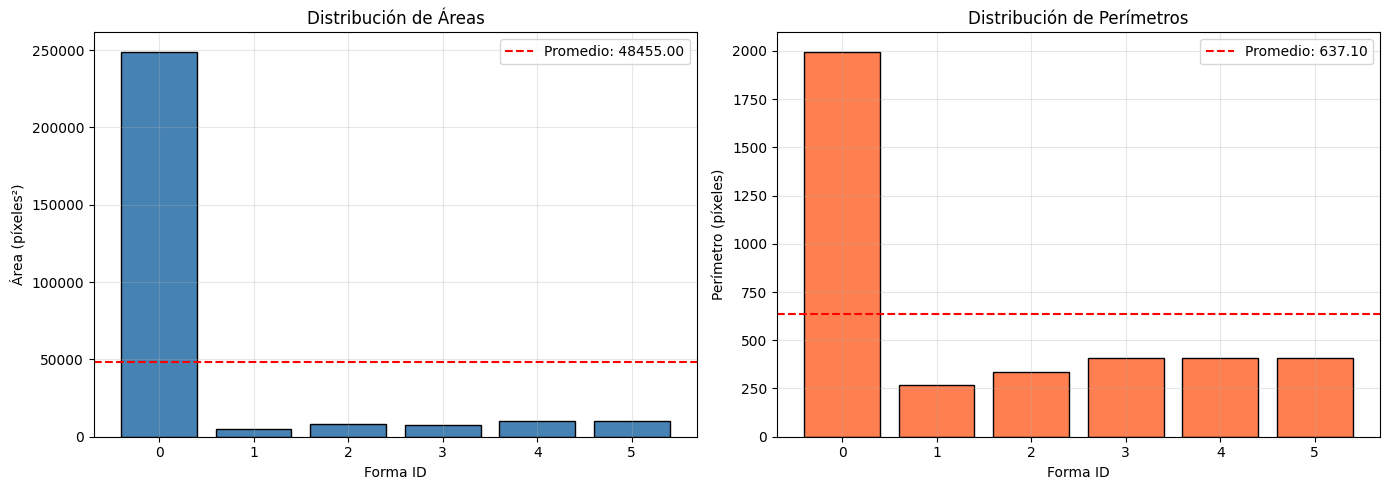

In [13]:
# Crear gráficos de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de áreas
axes[0].bar(range(len(areas)), areas, color='steelblue', edgecolor='black')
axes[0].axhline(y=area_promedio, color='red', linestyle='--', label=f'Promedio: {area_promedio:.2f}')
axes[0].set_xlabel('Forma ID')
axes[0].set_ylabel('Área (píxeles²)')
axes[0].set_title('Distribución de Áreas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de perímetros
axes[1].bar(range(len(perimeters)), perimeters, color='coral', edgecolor='black')
axes[1].axhline(y=perimeter_promedio, color='red', linestyle='--', label=f'Promedio: {perimeter_promedio:.2f}')
axes[1].set_xlabel('Forma ID')
axes[1].set_ylabel('Perímetro (píxeles)')
axes[1].set_title('Distribución de Perímetros')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_distribucion_metricas.png'), dpi=100, bbox_inches='tight')
plt.show()

## 13. Bonus: Visualización Morfológica de Operaciones

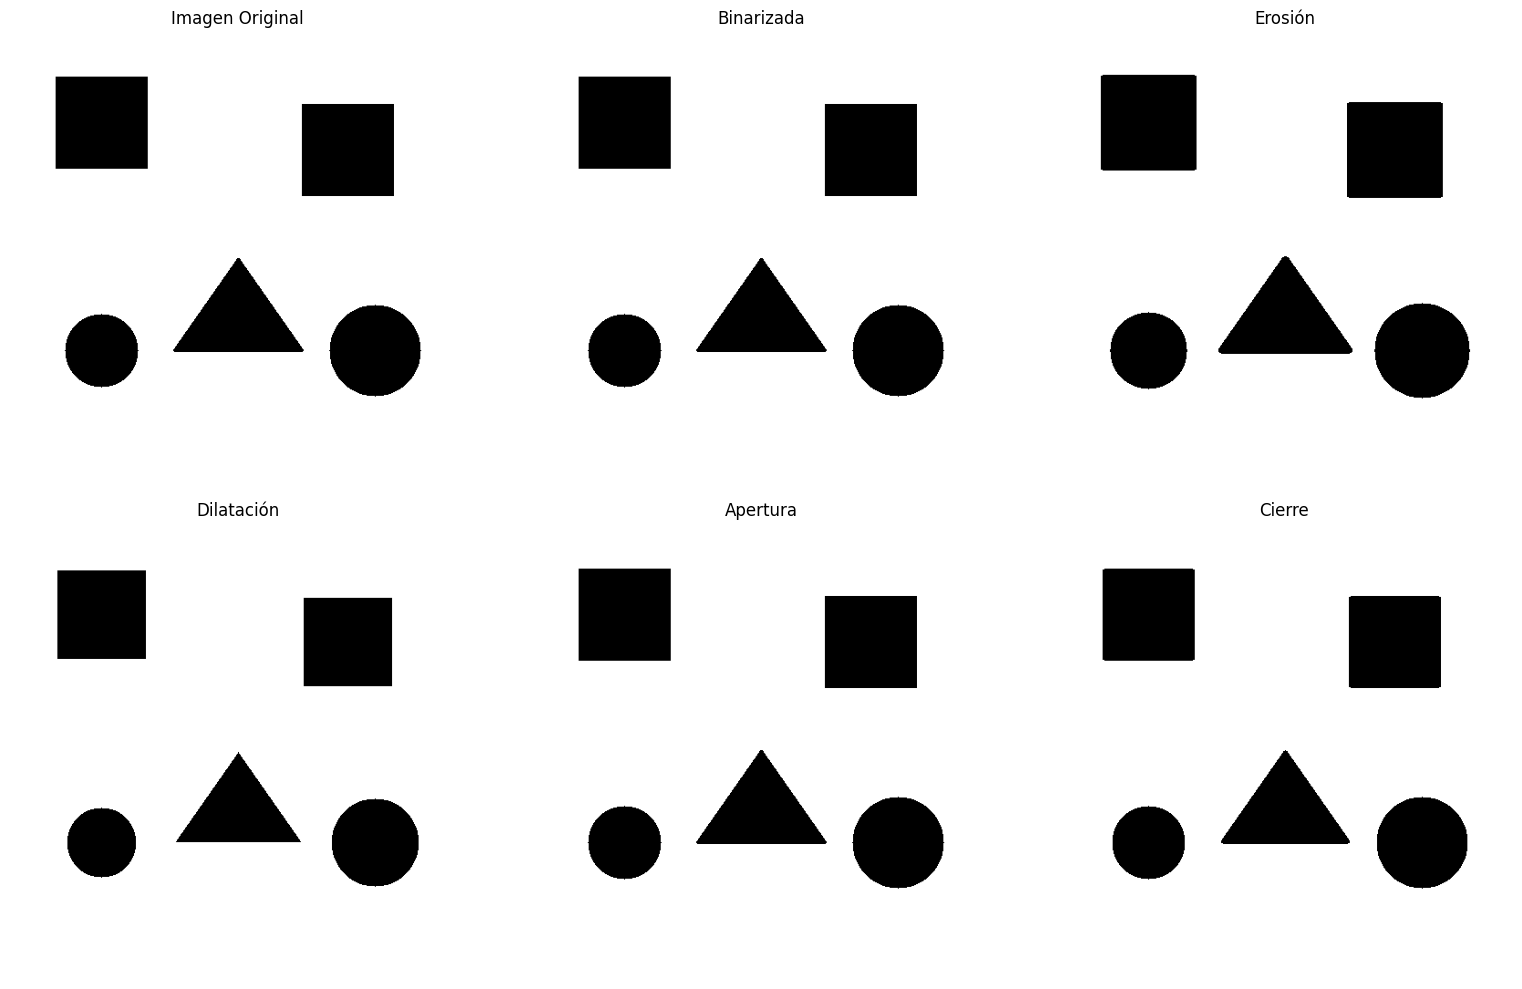

Operaciones morfológicas completadas


In [10]:
# Crear kernel para operaciones morfológicas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Aplicar erosión
eroded = cv2.erode(binary_fixed, kernel, iterations=1)

# Aplicar dilatación
dilated = cv2.dilate(binary_fixed, kernel, iterations=1)

# Aplicar apertura (erosión seguida de dilatación)
opening = cv2.morphologyEx(binary_fixed, cv2.MORPH_OPEN, kernel)

# Aplicar cierre (dilatación seguida de erosión)
closing = cv2.morphologyEx(binary_fixed, cv2.MORPH_CLOSE, kernel)

# Visualizar todas las operaciones
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Imagen Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_fixed, cmap='gray')
axes[0, 1].set_title('Binarizada')
axes[0, 1].axis('off')

axes[0, 2].imshow(eroded, cmap='gray')
axes[0, 2].set_title('Erosión')
axes[0, 2].axis('off')

axes[1, 0].imshow(dilated, cmap='gray')
axes[1, 0].set_title('Dilatación')
axes[1, 0].axis('off')

axes[1, 1].imshow(opening, cmap='gray')
axes[1, 1].set_title('Apertura')
axes[1, 1].axis('off')

axes[1, 2].imshow(closing, cmap='gray')
axes[1, 2].set_title('Cierre')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '09_operaciones_morfologicas.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Operaciones morfológicas completadas")

## 14. Resumen de Archivos Generados

In [11]:
# Listar todos los archivos generados
output_files = os.listdir(OUTPUT_DIR)
output_files.sort()

print("\n" + "="*60)
print("ARCHIVOS GENERADOS EN CARPETA MEDIA/")
print("="*60)
for i, file in enumerate(output_files, 1):
    file_path = os.path.join(OUTPUT_DIR, file)
    file_size = os.path.getsize(file_path) / 1024  # en KB
    print(f"{i}. {file} ({file_size:.2f} KB)")
print("="*60)
print(f"\nTotal de archivos generados: {len(output_files)}")


ARCHIVOS GENERADOS EN CARPETA MEDIA/
1. 01_imagen_original.png (3.03 KB)
2. 01_imagen_original_viz.png (16.84 KB)
3. 02_umbral_fijo.png (3.03 KB)
4. 02_umbral_fijo_viz.png (17.63 KB)
5. 03_comparacion_umbrales.png (25.31 KB)
6. 03_umbral_adaptativo.png (4.28 KB)
7. 04_contornos_dibujados.png (7.66 KB)
8. 04_contornos_dibujados_viz.png (30.11 KB)
9. 05_bounding_boxes.png (8.13 KB)
10. 05_bounding_boxes_viz.png (25.01 KB)
11. 09_operaciones_morfologicas.png (38.65 KB)

Total de archivos generados: 11
